<>:76: SyntaxWarning: invalid escape sequence '\o'
<>:76: SyntaxWarning: invalid escape sequence '\o'
/var/folders/r1/8fnw2qyd6vs6x4fvg2cghqzh0000gn/T/ipykernel_4053/847667045.py:76: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Time $[1/\omega_p]$')
/var/folders/r1/8fnw2qyd6vs6x4fvg2cghqzh0000gn/T/ipykernel_4053/847667045.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfield = pd.read_csv(filename1, delim_whitespace=True, header=1, nrows=5)
/var/folders/r1/8fnw2qyd6vs6x4fvg2cghqzh0000gn/T/ipykernel_4053/847667045.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  delec = pd.read_csv(filename2, delim_whitespace=True, header=1, nrows=5)


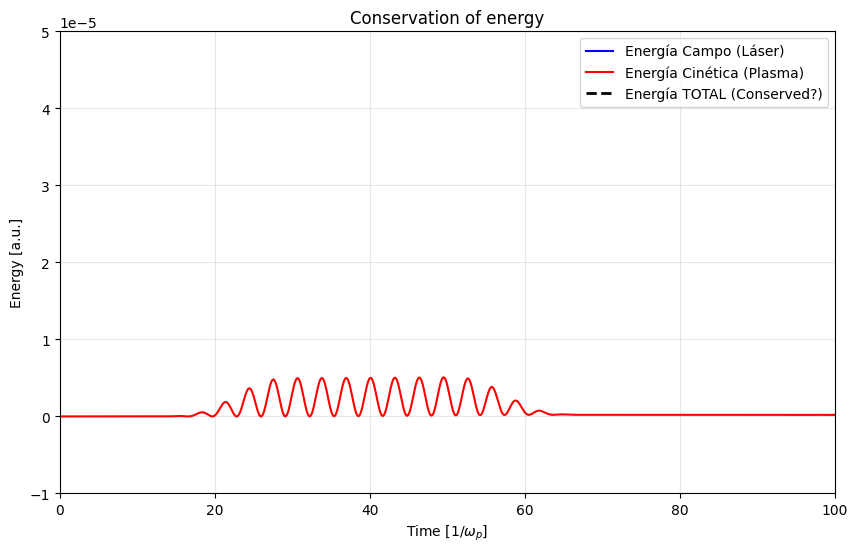

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson  
import pandas as pd


filename1 =('/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/rf_big/HIST/fld_ene')
filename2 =('/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/rf_big/HIST/par01_ene')

# 'header=1' significa que la fila 0 es basura (!) y la fila 1 son los nombres
dfield = pd.read_csv(filename1, delim_whitespace=True, header=1, nrows=5)
delec = pd.read_csv(filename2, delim_whitespace=True, header=1, nrows=5)

#print(dfield.columns)  # <--- Esto es el equivalente a .keys()
#print(dfield.head())   # <--- Te muestra la tablita


#print(delec.columns)  # <--- Esto es el equivalente a .keys()
#print(delec.head())   # <--- Te muestra la tablita

# --- HIST read function ---
def hist(archivo):
    try:
        # skiprows=2: we skip the first 2 text rows
        datos = np.loadtxt(archivo, skiprows=2)
        return datos
    except Exception as e:
        print(f"Error leyendo {archivo}: {e}")
        return None

#reading the files
data_fld = hist(filename1)
data_par = hist(filename2)

if data_fld is not None and data_par is not None:
    # --- PROCESAR CAMPO (FLD) ---
    # data_fld tiene columnas: Iter, Time, B1, B2, B3, E1, E2, E3
    # Indices: 0=Iter, 1=Time, 2=B1 ... 7=E3
    
    t = data_fld[:, 1]  # Tiempo
    
    # Sumamos toda la energía electromagnética (E^2 + B^2)
    # Sumamos desde la columna 2 hasta la 7 (todas las componentes)
    E_campo_total = np.sum(data_fld[:, 2:8], axis=1)

    # --- PROCESAR PLASMA (PAR) ---
    # data_par tiene columnas: Iter, Time, Total, Par., Kin. Energy ...
    # Normalmente:
    # Col 0: Iter
    # Col 1: Time
    # Col 2: Kinetic Energy (Suele ser la columna 2 o 3, probemos la 2 que es la estándar)
    
    # TRUCO: A veces la columna 'Total' es el número de partículas y no energía.
    # Vamos a probar con la columna 2. Si se ve constante y gigante, es número de partículas.
    # Si empieza en 0 y sube, es energía.
    E_plasma = data_par[:, 3] 

    # --- ASEGURAR TAMAÑOS ---
    n = min(len(t), len(E_plasma))
    t = t[:n]
    E_campo_total = E_campo_total[:n]
    E_plasma = E_plasma[:n]

    # --- LA SUMA MAESTRA ---
    E_total_sistema = E_campo_total + E_plasma

    # --- GRAFICAR ---
    plt.figure(figsize=(10, 6))
    
    plt.plot(t, E_campo_total, label='Energía Campo (Láser)', color='blue')
    plt.plot(t, E_plasma, label='Energía Cinética (Plasma)', color='red')
    
    # Esta es la prueba de fuego:
    plt.plot(t, E_total_sistema, label='Energía TOTAL (Conserved?)', color='black', linestyle='--', linewidth=2)

    plt.xlabel('Time $[1/\omega_p]$')
    plt.ylabel('Energy [a.u.]')
    plt.title('Conservation of energy')
    plt.legend()
    plt.xlim(0,100)
    plt.ylim(-0.00001,0.00005)
    plt.grid(True, alpha=0.3)
    plt.savefig('Conservation of energy n=1_d=100.png')
    plt.show()
    


else:
    print("Algo falló al cargar. Revisa las rutas y si los archivos tienen extensión .h5 o no.")




